# ML 프로젝트 데이터 전처리
## 다중 데이터셋 병합 (Climate, Crop, Landuse, Livestock, Disease)

**목표**: disease 데이터(488 rows)를 기준으로 다른 데이터셋들을 병합하여 infection_rate 예측을 위한 통합 데이터셋 생성

## 1. 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. 데이터 로드

각 데이터셋을 로드합니다.

In [3]:
# 파일 경로 설정
climate_path = '../../../data/interim/climate/sorted_climate_data.csv'
crop_path = '../../../data/interim/crop/processed_crop.csv'
landuse_2015_path = '../../../data/interim/landuse/processed_landuse_2015.csv'
landuse_2019_path = '../../../data/interim/landuse/processed_landuse_2019.csv'  # 여기선 사용하지 않음
livestock_path = '../../../data/interim/livestock/processed_livestock.csv'
disease_path = '../../../data/interim/disease/processed_HIV_rates.csv'

# 데이터 로드
print("Loading datasets...")
climate_df = pd.read_csv(climate_path)
crop_df = pd.read_csv(crop_path)
landuse_2015 = pd.read_csv(landuse_2015_path)
livestock_df = pd.read_csv(livestock_path)
disease_df = pd.read_csv(disease_path)

print("✓ All datasets loaded successfully!")

Loading datasets...
✓ All datasets loaded successfully!


## 3. 데이터 구조 확인

In [4]:
print("=== Climate Data ===")
print(f"Shape: {climate_df.shape}")
print(f"Columns: {climate_df.columns.tolist()}")
print(f"\nFirst few rows:")
display(climate_df.head())

print("\n" + "="*50 + "\n")

print("=== Crop Data ===")
print(f"Shape: {crop_df.shape}")
print(f"Columns: {crop_df.columns.tolist()}")
print(f"\nFirst few rows:")
display(crop_df.head())

print("\n" + "="*50 + "\n")

print("=== Landuse 2015 Data ===")
print(f"Shape: {landuse_2015.shape}")
print(f"Columns: {landuse_2015.columns.tolist()}")
print(f"\nFirst few rows:")
display(landuse_2015.head())

print("\n" + "="*50 + "\n")

print("=== Livestock Data ===")
print(f"Shape: {livestock_df.shape}")
print(f"Columns: {livestock_df.columns.tolist()}")
print(f"\nFirst few rows:")
display(livestock_df.head())

print("\n" + "="*50 + "\n")

print("=== Disease Data (Base) ===")
print(f"Shape: {disease_df.shape}")
print(f"Columns: {disease_df.columns.tolist()}")
print(f"\nFirst few rows:")
display(disease_df.head())

=== Climate Data ===
Shape: (15600, 6)
Columns: ['country', 'admin', 'max_temperature', 'min_temperature', 'avg_temperature', 'year']

First few rows:


,country,admin,max_temperature,min_temperature,avg_temperature,year
0,Nigeria,Abia,302.49878,297.92114,299.90726,2001
1,Nigeria,Abia,302.06738,298.08618,299.77386,2002
2,Nigeria,Abia,302.21460,298.23804,299.98386,2003
3,Nigeria,Abia,302.61304,298.12598,300.07108,2004
4,Nigeria,Abia,302.97754,298.20850,300.25198,2005




=== Crop Data ===
Shape: (3501, 9)
Columns: ['country', 'country_code', 'admin_1', 'L1_GID', 'harvest_year', 'Cereals_Prod_Ton', 'Roots_tubers_Prod_Ton', 'Legumes_pulses_Prod_Ton', 'Cash_crops_Prod_Ton']

First few rows:


,country,country_code,admin_1,L1_GID,harvest_year,Cereals_Prod_Ton,Roots_tubers_Prod_Ton,Legumes_pulses_Prod_Ton,Cash_crops_Prod_Ton
0,Angola,AO,Bengo,L1AGO0035,1997,0.610000,3.50000,0.0,0.0
1,Angola,AO,Bengo,L1AGO0035,1998,0.700000,6.50000,0.0,0.0
2,Angola,AO,Bengo,L1AGO0035,1999,0.899956,6.00000,0.0,0.0
3,Angola,AO,Bengo,L1AGO0035,2000,1.199960,9.00000,0.0,0.0
4,Angola,AO,Bengo,L1AGO0035,2001,0.600031,8.99553,0.0,0.0




=== Landuse 2015 Data ===
Shape: (859, 5)
Columns: ['ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE', 'ADM1_NAME', 'rate_landuse']

First few rows:


,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,rate_landuse
0,220,Seychelles,61184,Mont Fleuri,0.960938
1,29,Benin,616,Littoral,0.940552
2,220,Seychelles,61179,Les Mamelles,0.921875
3,220,Seychelles,61183,Mont Buxton,0.912109
4,253,Uganda,42182,Kampala,0.905169




=== Livestock Data ===
Shape: (5796, 13)
Columns: ['ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE', 'ADM1_NAME', 'year', 'Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']

First few rows:


,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,year,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine
0,8,Angola,398,Bengo,2001,0.0,0.352811,16.751916,0.0,1.945433,0.001210,0.350924,0.578892
1,8,Angola,398,Bengo,2002,0.0,0.342582,17.010857,0.0,2.113258,0.000992,0.394502,0.651813
2,8,Angola,398,Bengo,2003,0.0,0.334268,17.242436,0.0,2.306114,0.001749,0.456317,0.727884
3,8,Angola,398,Bengo,2004,0.0,0.325620,17.555852,0.0,2.398938,0.002005,0.518402,0.813876
4,8,Angola,398,Bengo,2005,0.0,0.360941,17.131548,0.0,2.593782,0.001683,0.611763,0.807754




=== Disease Data (Base) ===
Shape: (488, 4)
Columns: ['year', 'country', 'region_name', 'infection_rate']

First few rows:


,year,country,region_name,infection_rate
0,2010,Burkina Faso,Boucle Du Mouhoun,0.585652
1,2010,Burkina Faso,Cascades,0.979432
2,2010,Burkina Faso,Centre,1.955671
3,2010,Burkina Faso,Centre-est,1.037736
4,2010,Burkina Faso,Centre-nord,0.379147


## 4. 컬럼명 표준화

모든 데이터셋의 컬럼명을 `country`, `admin`, `year` 형식으로 통일합니다.

In [5]:
# Disease (기준 데이터)
base_df = disease_df[['year', 'country', 'region_name', 'infection_rate']].copy()
base_df = base_df.rename(columns={'region_name': 'admin'})

print(f"Base (disease) columns: {base_df.columns.tolist()}")
print(f"Base shape: {base_df.shape}")

Base (disease) columns: ['year', 'country', 'admin', 'infection_rate']
Base shape: (488, 4)


In [6]:
# Climate - 이미 country, admin, year 형식이라고 가정
# 만약 다른 이름이면 아래 주석을 해제하고 수정
climate_clean = climate_df.copy()
# climate_clean = climate_clean.rename(columns={'기존컬럼명': 'country', '기존컬럼명2': 'admin'})

climate_clean = climate_clean[['country', 'admin', 'year', 
                                'max_temperature', 'min_temperature', 'avg_temperature']]

print(f"Climate columns: {climate_clean.columns.tolist()}")
print(f"Climate shape: {climate_clean.shape}")

Climate columns: ['country', 'admin', 'year', 'max_temperature', 'min_temperature', 'avg_temperature']
Climate shape: (15600, 6)


In [7]:
# Crop
crop_clean = crop_df[['country', 'admin_1', 'harvest_year',
                       'Cereals_Prod_Ton', 'Roots_tubers_Prod_Ton', 
                       'Legumes_pulses_Prod_Ton', 'Cash_crops_Prod_Ton']].copy()

crop_clean = crop_clean.rename(columns={
    'admin_1': 'admin', 
    'harvest_year': 'year'
})

print(f"Crop columns: {crop_clean.columns.tolist()}")
print(f"Crop shape: {crop_clean.shape}")

Crop columns: ['country', 'admin', 'year', 'Cereals_Prod_Ton', 'Roots_tubers_Prod_Ton', 'Legumes_pulses_Prod_Ton', 'Cash_crops_Prod_Ton']
Crop shape: (3501, 7)


In [8]:
# Livestock
livestock_clean = livestock_df[['ADM0_NAME', 'ADM1_NAME', 'year',
                                 'Buffa', 'Cattl', 'Chick', 'Ducks', 
                                 'Goats', 'Horse', 'Sheep', 'Swine']].copy()

livestock_clean = livestock_clean.rename(columns={
    'ADM0_NAME': 'country', 
    'ADM1_NAME': 'admin'
})

print(f"Livestock columns: {livestock_clean.columns.tolist()}")
print(f"Livestock shape: {livestock_clean.shape}")

Livestock columns: ['country', 'admin', 'year', 'Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
Livestock shape: (5796, 11)


In [9]:
# Landuse - 2015년 데이터만 사용 (year 컬럼 제거)
landuse_clean = landuse_2015[['ADM0_NAME', 'ADM1_NAME', 'rate_landuse']].copy()

landuse_clean = landuse_clean.rename(columns={
    'ADM0_NAME': 'country', 
    'ADM1_NAME': 'admin'
})

print(f"Landuse columns: {landuse_clean.columns.tolist()}")
print(f"Landuse shape: {landuse_clean.shape}")
print("\nNote: Landuse 2015 data will be applied to all years")

Landuse columns: ['country', 'admin', 'rate_landuse']
Landuse shape: (859, 3)

Note: Landuse 2015 data will be applied to all years


## 5. 데이터 병합 전 검증

각 데이터셋의 국가-행정구역 조합을 확인하여 매칭 가능 여부를 검증합니다.

In [10]:
# 각 데이터셋의 국가-행정구역 조합 확인
disease_regions = set(zip(base_df['country'], base_df['admin']))
climate_regions = set(zip(climate_clean['country'], climate_clean['admin']))
crop_regions = set(zip(crop_clean['country'], crop_clean['admin']))
livestock_regions = set(zip(livestock_clean['country'], livestock_clean['admin']))
landuse_regions = set(zip(landuse_clean['country'], landuse_clean['admin']))

print("=== Country-Admin Combinations ===")
print(f"Disease regions: {len(disease_regions)}")
print(f"Climate regions: {len(climate_regions)}")
print(f"Crop regions: {len(crop_regions)}")
print(f"Livestock regions: {len(livestock_regions)}")
print(f"Landuse regions: {len(landuse_regions)}")

=== Country-Admin Combinations ===
Disease regions: 256
Climate regions: 780
Crop regions: 178
Livestock regions: 276
Landuse regions: 859


In [12]:
# Disease에는 있는데 다른 데이터에 없는 지역 확인
print("=== Regions in Disease but missing in other datasets ===")
print(f"Missing in Climate: {len(disease_regions - climate_regions)}")
print(f"Missing in Crop: {len(disease_regions - crop_regions)}")
print(f"Missing in Livestock: {len(disease_regions - livestock_regions)}")
print(f"Missing in Landuse: {len(disease_regions - landuse_regions)}")

# 구체적으로 어떤 지역이 빠졌는지 확인
if len(disease_regions - climate_regions) > 0:
    print("\nMissing in Climate:")
    for region in list(disease_regions - climate_regions):
        print(f"  - {region}")

if len(disease_regions - crop_regions) > 0:
    print("\nMissing in Crop:")
    for region in list(disease_regions - crop_regions):
        print(f"  - {region}")

if len(disease_regions - livestock_regions) > 0:
    print("\nMissing in Livestock:")
    for region in list(disease_regions - livestock_regions):
        print(f"  - {region}")

if len(disease_regions - landuse_regions) > 0:
    print("\nMissing in Landuse:")
    for region in list(disease_regions - landuse_regions):
        print(f"  - {region}")

=== Regions in Disease but missing in other datasets ===
Missing in Climate: 2
Missing in Crop: 82
Missing in Livestock: 1
Missing in Landuse: 1

Missing in Climate:
  - ('Senegal', 'Dakar')
  - ('South Africa', 'Western Cape')

Missing in Crop:
  - ('Togo', 'Plateaux')
  - ('Congo', 'Niari')
  - ('Gabon', 'Estuaire')
  - ('Congo', 'Likouala')
  - ('Ghana', 'Brong Ahafo')
  - ('Sao Tome and Principe', 'Sao Tome')
  - ('Gabon', 'Ogooue-lolo')
  - ('Namibia', 'Omusati')
  - ('Niger', 'Dosso')
  - ('Ghana', 'Upper West')
  - ('Namibia', 'Oshana')
  - ('Burundi', 'Bujumbura Mairie')
  - ('Democratic Republic of the Congo', 'Sud-Kivu')
  - ('Namibia', 'Karas')
  - ('Namibia', 'Hardap')
  - ('Togo', 'Savanes')
  - ('Ghana', 'Central')
  - ('Gambia', 'Kanifing Municipal Council')
  - ('Democratic Republic of the Congo', 'Orientale')
  - ('Ghana', 'Upper East')
  - ('Gambia', 'North Bank')
  - ('Namibia', 'Otjozondjupa')
  - ('Zimbabwe', 'Bulawayo')
  - ('Ghana', 'Eastern')
  - ('Gabon', 'Haut

In [13]:
# 연도 범위 확인
print("=== Year Range in Each Dataset ===")
print(f"Disease: {base_df['year'].min()} - {base_df['year'].max()}")
print(f"Climate: {climate_clean['year'].min()} - {climate_clean['year'].max()}")
print(f"Crop: {crop_clean['year'].min()} - {crop_clean['year'].max()}")
print(f"Livestock: {livestock_clean['year'].min()} - {livestock_clean['year'].max()}")
print(f"Landuse: 2015 (fixed)")

=== Year Range in Each Dataset ===
Disease: 2001 - 2023
Climate: 2001 - 2020
Crop: 1974 - 2023
Livestock: 2001 - 2021
Landuse: 2015 (fixed)


In [35]:
print("=== Checking for duplicates ===")
print(f"Climate duplicates: {climate_clean.duplicated(subset=['country', 'admin', 'year']).sum()}")
print(f"Crop duplicates: {crop_clean.duplicated(subset=['country', 'admin', 'year']).sum()}")
print(f"Livestock duplicates: {livestock_clean.duplicated(subset=['country', 'admin', 'year']).sum()}")
print(f"Landuse duplicates: {landuse_clean.duplicated(subset=['country', 'admin']).sum()}")

=== Checking for duplicates ===
Climate duplicates: 0
Crop duplicates: 0
Livestock duplicates: 0
Landuse duplicates: 0


In [36]:
# Crop 데이터의 중복 상세 분석
print("=== Crop Duplicates Analysis ===")

# 중복된 (country, admin, year) 조합 찾기
duplicate_mask = crop_clean.duplicated(subset=['country', 'admin', 'year'], keep=False)
crop_duplicates = crop_clean[duplicate_mask].sort_values(['country', 'admin', 'year'])

print(f"Total rows in crop with duplicates: {duplicate_mask.sum()}")
print(f"Unique (country, admin, year) combinations that are duplicated: {crop_clean[duplicate_mask].drop_duplicates(subset=['country', 'admin', 'year']).shape[0]}")

print("\nDuplicated entries:")
print(crop_duplicates[['country', 'admin', 'year']])

# 중복 조합 중 Disease와 겹치는 것만 확인
disease_keys = set(zip(base_df['country'], base_df['admin'], base_df['year']))
crop_keys = set(zip(crop_clean['country'], crop_clean['admin'], crop_clean['year']))

crop_dup_keys = set(zip(crop_duplicates['country'], crop_duplicates['admin'], crop_duplicates['year']))
matching_duplicates = disease_keys & crop_dup_keys

print(f"\nDuplicated crop entries that match with disease data: {len(matching_duplicates)}")

=== Crop Duplicates Analysis ===
Total rows in crop with duplicates: 0
Unique (country, admin, year) combinations that are duplicated: 0

Duplicated entries:
Empty DataFrame
Columns: [country, admin, year]
Index: []

Duplicated crop entries that match with disease data: 0


In [37]:
# 실제로 중복이 어떤 형태인지 확인
print("=== Detailed Duplicate Check ===")

# (country, admin, year) 조합별 개수
key_counts = crop_clean.groupby(['country', 'admin', 'year']).size()
duplicated_keys = key_counts[key_counts > 1]

print(f"Number of (country, admin, year) combinations that appear multiple times: {len(duplicated_keys)}")

if len(duplicated_keys) > 0:
    print(f"\nSample of duplicated combinations:")
    print(duplicated_keys.head())
    
    # 구체적인 예시 보기
    example = duplicated_keys.index[0]
    print(f"\nExample: country={example[0]}, admin={example[1]}, year={example[2]}")
    print("All rows with this combination:")
    example_rows = crop_clean[(crop_clean['country'] == example[0]) & 
                               (crop_clean['admin'] == example[1]) & 
                               (crop_clean['year'] == example[2])]
    print(example_rows)
    print(f"\nAre all columns identical? {example_rows.duplicated().any()}")

=== Detailed Duplicate Check ===
Number of (country, admin, year) combinations that appear multiple times: 0


In [38]:
# 중복 제거 (평균값 사용)
print("Removing duplicates from Crop data...")
print(f"Before: {crop_clean.shape}")

# 수치형 컬럼만 평균, 비수치형은 첫 번째 값
numeric_cols = crop_clean.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [col for col in crop_clean.columns if col not in numeric_cols and col not in ['country', 'admin', 'year']]

# 그룹별 집계
crop_clean_dedup = crop_clean.groupby(['country', 'admin', 'year'], as_index=False).agg({
    **{col: 'mean' for col in numeric_cols if col not in ['country', 'admin', 'year']},
    **{col: 'first' for col in non_numeric_cols}
})

print(f"After: {crop_clean_dedup.shape}")
print(f"Removed {crop_clean.shape[0] - crop_clean_dedup.shape[0]} duplicate rows")

# 이제 이걸로 병합
crop_clean = crop_clean_dedup

Removing duplicates from Crop data...
Before: (3262, 7)
After: (3262, 7)
Removed 0 duplicate rows


## 6. 데이터 병합

Disease 데이터를 기준으로 left join을 수행합니다.
- Climate, Crop, Livestock: `country`, `admin`, `year`로 매칭
- Landuse: `country`, `admin`만으로 매칭 (모든 연도에 2015년 데이터 적용)

In [39]:
# 병합 시작
result = base_df.copy()
print(f"Starting with base dataframe: {result.shape}")

Starting with base dataframe: (488, 4)


In [40]:
# Climate 병합
result = result.merge(
    climate_clean,
    on=['country', 'admin', 'year'],
    how='left'
)
print(f"After merging Climate: {result.shape}")

After merging Climate: (488, 7)


In [41]:
# Crop 병합
result = result.merge(
    crop_clean,
    on=['country', 'admin', 'year'],
    how='left'
)
print(f"After merging Crop: {result.shape}")

After merging Crop: (488, 11)


In [42]:
# Livestock 병합
result = result.merge(
    livestock_clean,
    on=['country', 'admin', 'year'],
    how='left'
)
print(f"After merging Livestock: {result.shape}")

After merging Livestock: (488, 19)


In [43]:
# Landuse 병합 (year 제외)
result = result.merge(
    landuse_clean,
    on=['country', 'admin'],
    how='left'
)
print(f"After merging Landuse: {result.shape}")
print(f"\n✓ All datasets merged successfully!")

After merging Landuse: (488, 20)

✓ All datasets merged successfully!


In [44]:
# 최종 결과 확인
print("=== Final Merged Dataset ===")
print(f"Shape: {result.shape}")
print(f"\nColumns: {result.columns.tolist()}")
print(f"\nFirst few rows:")
display(result.head(10))

=== Final Merged Dataset ===
Shape: (488, 20)

Columns: ['year', 'country', 'admin', 'infection_rate', 'max_temperature', 'min_temperature', 'avg_temperature', 'Cereals_Prod_Ton', 'Roots_tubers_Prod_Ton', 'Legumes_pulses_Prod_Ton', 'Cash_crops_Prod_Ton', 'Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine', 'rate_landuse']

First few rows:


,year,country,admin,infection_rate,max_temperature,min_temperature,avg_temperature,Cereals_Prod_Ton,Roots_tubers_Prod_Ton,Legumes_pulses_Prod_Ton,Cash_crops_Prod_Ton,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse
0,2010,Burkina Faso,Boucle Du Mouhoun,0.585652,307.42114,297.76172,302.50760,6.547875,15.162796,7.106732,1.376400,0.0,25.000049,164.065700,0.0,34.153420,0.693863,21.774243,9.682960,0.076206
1,2010,Burkina Faso,Cascades,0.979432,304.47192,297.88160,300.27893,6.199006,8.444137,3.488444,1.007438,0.0,38.008688,96.864817,0.0,12.506484,0.008877,12.373391,3.865450,0.074387
2,2010,Burkina Faso,Centre,1.955671,307.73170,299.50660,302.80447,5.874458,1.000000,7.010313,0.000000,0.0,17.566445,303.908919,0.0,58.134766,0.019041,40.947445,6.821150,0.407856
3,2010,Burkina Faso,Centre-est,1.037736,307.41138,298.78003,302.61942,6.148647,15.963235,11.423430,1.151901,0.0,29.597071,203.094681,0.0,69.010943,0.027864,45.871831,18.292361,0.143950
4,2010,Burkina Faso,Centre-nord,0.379147,308.31274,297.82104,303.14368,4.455277,0.000000,9.927004,1.730627,0.0,28.843678,138.295650,0.0,65.134086,0.079677,48.346972,4.834737,0.120649
5,2010,Burkina Faso,Centre-ouest,1.622419,306.55396,299.12573,301.98790,3.969988,15.027778,15.404953,0.609386,0.0,4.144297,197.316045,0.0,32.718305,0.079125,25.059793,6.839734,0.121380
6,2010,Burkina Faso,Centre-sud,0.926784,306.74730,298.70190,302.07712,4.981574,13.329980,5.977472,0.728836,0.0,25.646751,248.165379,0.0,59.255066,0.005035,31.032994,13.007065,0.130138
7,2010,Burkina Faso,Est,0.957702,307.95923,297.30933,302.74704,5.111972,11.372032,6.668847,0.792422,0.0,22.987212,105.163249,0.0,31.965473,0.148155,19.576255,3.607876,0.056882
8,2010,Burkina Faso,Hauts-bassins,1.631543,305.89966,298.75854,301.59680,6.302863,14.993078,3.860467,1.152786,0.0,58.893784,129.289100,0.0,29.676095,0.009982,29.628014,11.868124,0.092157
9,2010,Burkina Faso,Nord,0.875657,307.55298,297.21558,302.34323,6.699213,14.695241,15.059540,1.472801,0.0,26.315218,177.275872,0.0,71.545219,0.542646,51.607829,10.399306,0.117150


## 7. 결측치 분석

In [45]:
# 결측치 개수 및 비율
missing_summary = pd.DataFrame({
    'Missing_Count': result.isnull().sum(),
    'Missing_Percentage': (result.isnull().sum() / len(result) * 100).round(2)
})

print("=== Missing Values Summary ===")
print(missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

=== Missing Values Summary ===
                         Missing_Count  Missing_Percentage
Cereals_Prod_Ton                   250               51.23
Roots_tubers_Prod_Ton              250               51.23
Legumes_pulses_Prod_Ton            250               51.23
Cash_crops_Prod_Ton                250               51.23
max_temperature                     15                3.07
min_temperature                     15                3.07
avg_temperature                     15                3.07
Buffa                               14                2.87
Cattl                               14                2.87
Chick                               14                2.87
Ducks                               14                2.87
Goats                               14                2.87
Horse                               14                2.87
Sheep                               14                2.87
Swine                               14                2.87
rate_landuse             

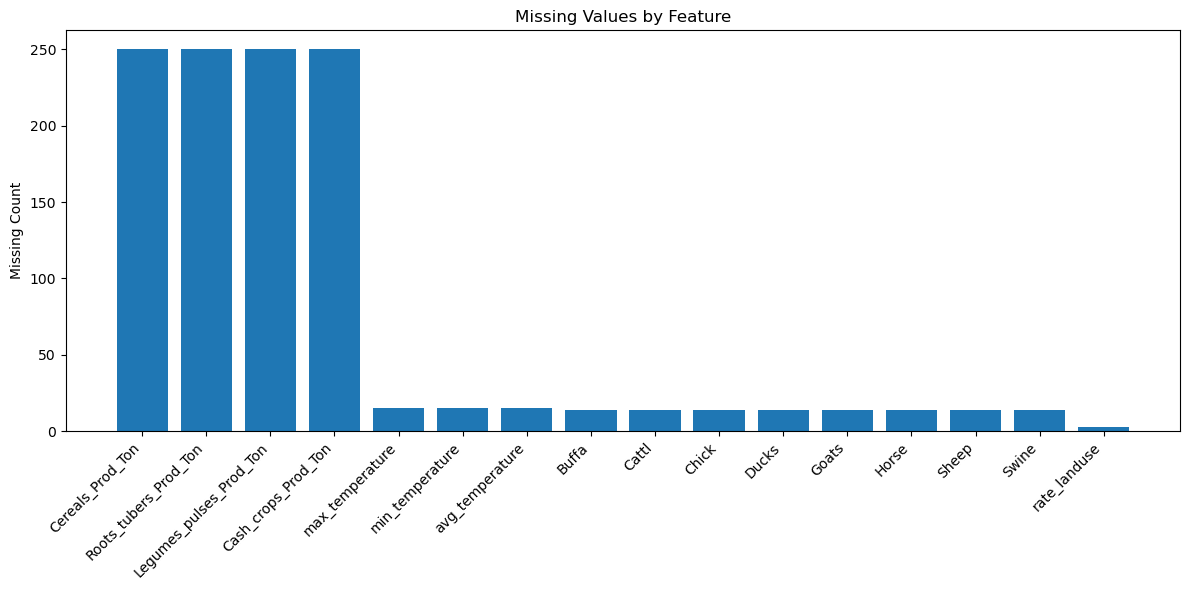

In [46]:
# 결측치 시각화
plt.figure(figsize=(12, 6))
missing_data = result.isnull().sum()[result.isnull().sum() > 0]
missing_data = missing_data.sort_values(ascending=False)

plt.bar(range(len(missing_data)), missing_data.values)
plt.xticks(range(len(missing_data)), missing_data.index, rotation=45, ha='right')
plt.ylabel('Missing Count')
plt.title('Missing Values by Feature')
plt.tight_layout()
plt.show()

In [ ]:
# 결측치 히트맵
plt.figure(figsize=(14, 8))
sns.heatmap(result.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Features')
plt.ylabel('Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. 기본 통계 분석

In [47]:
print("=== Data Summary ===")
print(f"Total rows: {len(result)}")
print(f"Total columns: {len(result.columns)}")
print(f"\nUnique countries: {result['country'].nunique()}")
print(f"Countries: {sorted(result['country'].unique())}")
print(f"\nUnique admin regions: {result['admin'].nunique()}")
print(f"\nYear range: {result['year'].min()} - {result['year'].max()}")
print(f"\nYear distribution:")
print(result['year'].value_counts().sort_index())

=== Data Summary ===
Total rows: 488
Total columns: 20

Unique countries: 28
Countries: ['Angola', 'Burkina Faso', 'Burundi', 'Cameroon', 'Chad', 'Congo', 'Democratic Republic of the Congo', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Kenya', 'Lesotho', 'Malawi', 'Mali', 'Mozambique', 'Namibia', 'Niger', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'South Africa', 'Swaziland', 'Togo', 'Zambia', 'Zimbabwe']

Unique admin regions: 242

Year range: 2001 - 2023

Year distribution:
year
2001     9
2003    31
2004    23
2005    30
2006    21
2007    11
2008    14
2009    30
2010    42
2011    21
2012    31
2013    48
2014    35
2015    41
2016    37
2017    14
2018    24
2019    15
2023    11
Name: count, dtype: int64


In [48]:
# 수치형 변수 기술통계
print("=== Descriptive Statistics ===")
display(result.describe())

=== Descriptive Statistics ===


,year,infection_rate,max_temperature,min_temperature,avg_temperature,Cereals_Prod_Ton,Roots_tubers_Prod_Ton,Legumes_pulses_Prod_Ton,Cash_crops_Prod_Ton,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse
count,488.000000,488.000000,473.000000,473.000000,473.000000,238.000000,238.000000,238.000000,238.000000,474.0,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,485.000000
mean,2011.231557,5.299082,300.919423,293.797237,297.503255,4.446867,8.875001,2.973202,1.958305,0.0,21.063972,502.169054,1.087301,25.422209,0.995588,18.419725,4.758984,0.119806
std,5.045346,6.550320,4.942571,5.574112,4.620090,9.838288,13.519866,8.805241,9.161329,0.0,28.770902,4102.592331,5.555509,33.583494,2.887020,28.476594,9.005598,0.174917
min,2001.000000,0.000000,287.423830,274.071530,282.297270,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000394
25%,2007.000000,1.012311,298.385000,292.032700,295.419650,1.294019,0.000000,0.488887,0.000000,0.0,3.498714,25.534511,0.000000,5.838599,0.002653,1.170958,0.338971,0.019163
50%,2012.000000,1.998738,300.922360,295.414550,298.334930,2.177630,3.661415,1.007987,0.000000,0.0,13.367907,61.886481,0.000000,14.935747,0.019299,9.769135,1.408599,0.053896
75%,2015.000000,7.262403,304.870120,297.678470,300.826480,4.952211,12.854838,1.992067,0.374303,0.0,27.472639,155.032951,0.168088,31.391405,0.429795,25.918651,4.615457,0.117150
max,2023.000000,27.073403,312.692870,302.017100,304.935330,134.207393,84.651534,100.004975,69.029158,0.0,257.216200,71733.611842,69.299351,264.313783,23.457133,264.498047,62.028182,0.839386


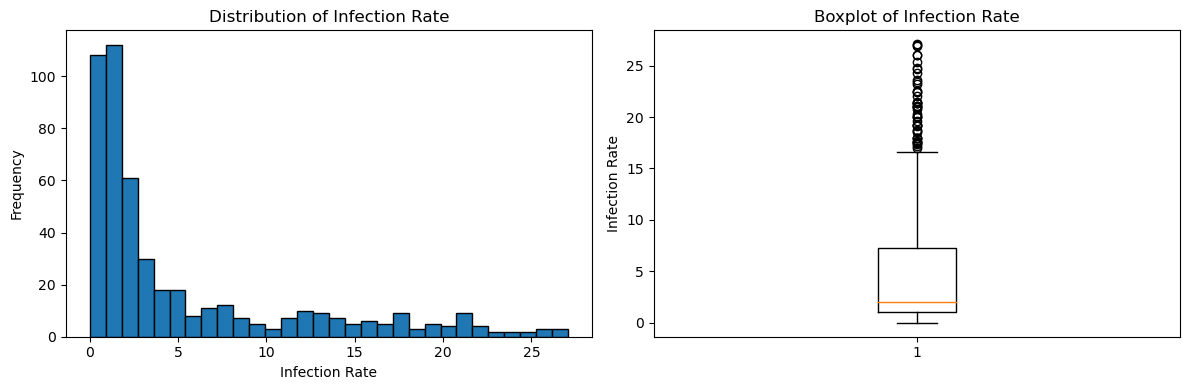

In [50]:
# Target 변수 (infection_rate) 분포
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(result['infection_rate'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Infection Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Infection Rate')

plt.subplot(1, 2, 2)
plt.boxplot(result['infection_rate'].dropna())
plt.ylabel('Infection Rate')
plt.title('Boxplot of Infection Rate')

plt.tight_layout()
plt.show()

## 9. 데이터 품질 체크

In [49]:
# 각 행의 결측치 비율
result['missing_ratio'] = result.isnull().sum(axis=1) / (len(result.columns) - 1)  # -1 for the new column

print("=== Row-wise Missing Data Analysis ===")
print(f"Rows with no missing values: {(result['missing_ratio'] == 0).sum()}")
print(f"Rows with < 25% missing: {(result['missing_ratio'] < 0.25).sum()}")
print(f"Rows with < 50% missing: {(result['missing_ratio'] < 0.50).sum()}")
print(f"Rows with >= 50% missing: {(result['missing_ratio'] >= 0.50).sum()}")

# missing_ratio 컬럼 제거
result = result.drop('missing_ratio', axis=1)

=== Row-wise Missing Data Analysis ===
Rows with no missing values: 236
Rows with < 25% missing: 471
Rows with < 50% missing: 475
Rows with >= 50% missing: 13


In [51]:
# 국가별 데이터 커버리지
country_coverage = result.groupby('country').apply(
    lambda x: (x.notna().sum().sum() - len(x) * 4) / (len(x) * (len(result.columns) - 4))  # 4: year, country, admin, infection_rate
).sort_values(ascending=False)

print("\n=== Data Coverage by Country ===")
for country, coverage in country_coverage.items():
    print(f"{country}: {coverage:.2%}")


=== Data Coverage by Country ===
Angola: 100.00%
Mozambique: 100.00%
Burkina Faso: 100.00%
Lesotho: 100.00%
Burundi: 98.53%
Chad: 98.08%
South Africa: 97.92%
Kenya: 96.88%
Mali: 95.83%
Zimbabwe: 95.00%
Ethiopia: 90.15%
Rwanda: 83.33%
Guinea: 83.33%
Malawi: 83.33%
Senegal: 82.53%
Cameroon: 78.01%
Gabon: 75.00%
Congo: 75.00%
Namibia: 75.00%
Niger: 75.00%
Gambia: 75.00%
Sao Tome and Principe: 75.00%
Sierra Leone: 75.00%
Swaziland: 75.00%
Togo: 75.00%
Zambia: 75.00%
Ghana: 75.00%
Democratic Republic of the Congo: 52.08%


## 10. 상관관계 분석 (간단 버전)

In [ ]:
# 수치형 변수들 간의 상관관계
numeric_cols = result.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = result[numeric_cols].corr()

# infection_rate와의 상관관계만 추출
if 'infection_rate' in correlation_matrix.columns:
    infection_corr = correlation_matrix['infection_rate'].sort_values(ascending=False)
    print("=== Correlation with Infection Rate ===")
    print(infection_corr[1:])  # infection_rate 자신 제외

In [ ]:
# 상관관계 히트맵 (전체)
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of All Numeric Features')
plt.tight_layout()
plt.show()

## 11. 데이터 저장

In [52]:
# CSV 파일로 저장
output_filename = 'merged_disease_dataset.csv'
result.to_csv(output_filename, index=False)
print(f"✓ Merged dataset saved to '{output_filename}'")
print(f"  Shape: {result.shape}")

✓ Merged dataset saved to 'merged_disease_dataset.csv'
  Shape: (488, 20)


In [ ]:
# 요약 정보를 텍스트 파일로 저장
with open('merge_summary.txt', 'w', encoding='utf-8') as f:
    f.write("=== Merged Dataset Summary ===\n\n")
    f.write(f"Final dataset shape: {result.shape}\n")
    f.write(f"Total rows: {len(result)}\n")
    f.write(f"Total columns: {len(result.columns)}\n\n")
    
    f.write("Columns:\n")
    for col in result.columns:
        f.write(f"  - {col}\n")
    
    f.write("\n=== Missing Values ===\n")
    missing_summary = pd.DataFrame({
        'Missing_Count': result.isnull().sum(),
        'Missing_Percentage': (result.isnull().sum() / len(result) * 100).round(2)
    })
    f.write(missing_summary[missing_summary['Missing_Count'] > 0].to_string())
    
    f.write("\n\n=== Data Info ===\n")
    f.write(f"Unique countries: {result['country'].nunique()}\n")
    f.write(f"Unique admin regions: {result['admin'].nunique()}\n")
    f.write(f"Year range: {result['year'].min()} - {result['year'].max()}\n")

print("✓ Summary saved to 'merge_summary.txt'")

## 12. 최종 확인

In [53]:
print("=== Final Check ===")
print(f"\n✓ Dataset successfully merged!")
print(f"✓ Shape: {result.shape}")
print(f"✓ Target variable (infection_rate) has {result['infection_rate'].notna().sum()} valid values")
print(f"✓ Overall missing data: {result.isnull().sum().sum() / result.size * 100:.2f}%")
print(f"\n✓ Ready for ML modeling!")

=== Final Check ===

✓ Dataset successfully merged!
✓ Shape: (488, 20)
✓ Target variable (infection_rate) has 488 valid values
✓ Overall missing data: 11.89%

✓ Ready for ML modeling!
